STEP 0 — LOAD DATA
customer_accounts   : (3000, 6)
billing_data        : (45596, 5)
monthly_usage       : (3000, 4)
nps_surveys         : (4400, 4)
support_tickets     : (25960, 6)

STEP 1A — FIX FORMAT TANGGAL SUPPORT TICKETS [F1]
Baris dengan format berbeda (DD-Mon-YY) : 1,345
NaT tersisa setelah fix                 : 778
✅ Format tanggal support_tickets seragam

STEP 1B — CLEANING PER FILE
plan_type unik     : ['enterprise', 'professional', 'starter']
contract_type unik : ['annual', 'monthly']

NPS score = -1 diganti NaN: 20 baris
✅ Cleaning per file selesai

STEP 1C — FIX subscription_date [F2]
Customer dengan tanggal dikoreksi (date_corrected=1): 1428
  → subscription_date diganti first_billing_date untuk 1428 customer

STEP 1D — TARGET VARIABLE & TENURE
Tenure negatif setelah fix: 45 customer
     customer_id effective_start unsubscribed_date  tenure_days
16        C-0017      2024-12-01        2024-10-25          -37
52        C-0053      2024-12-01        2024-11-07          -2

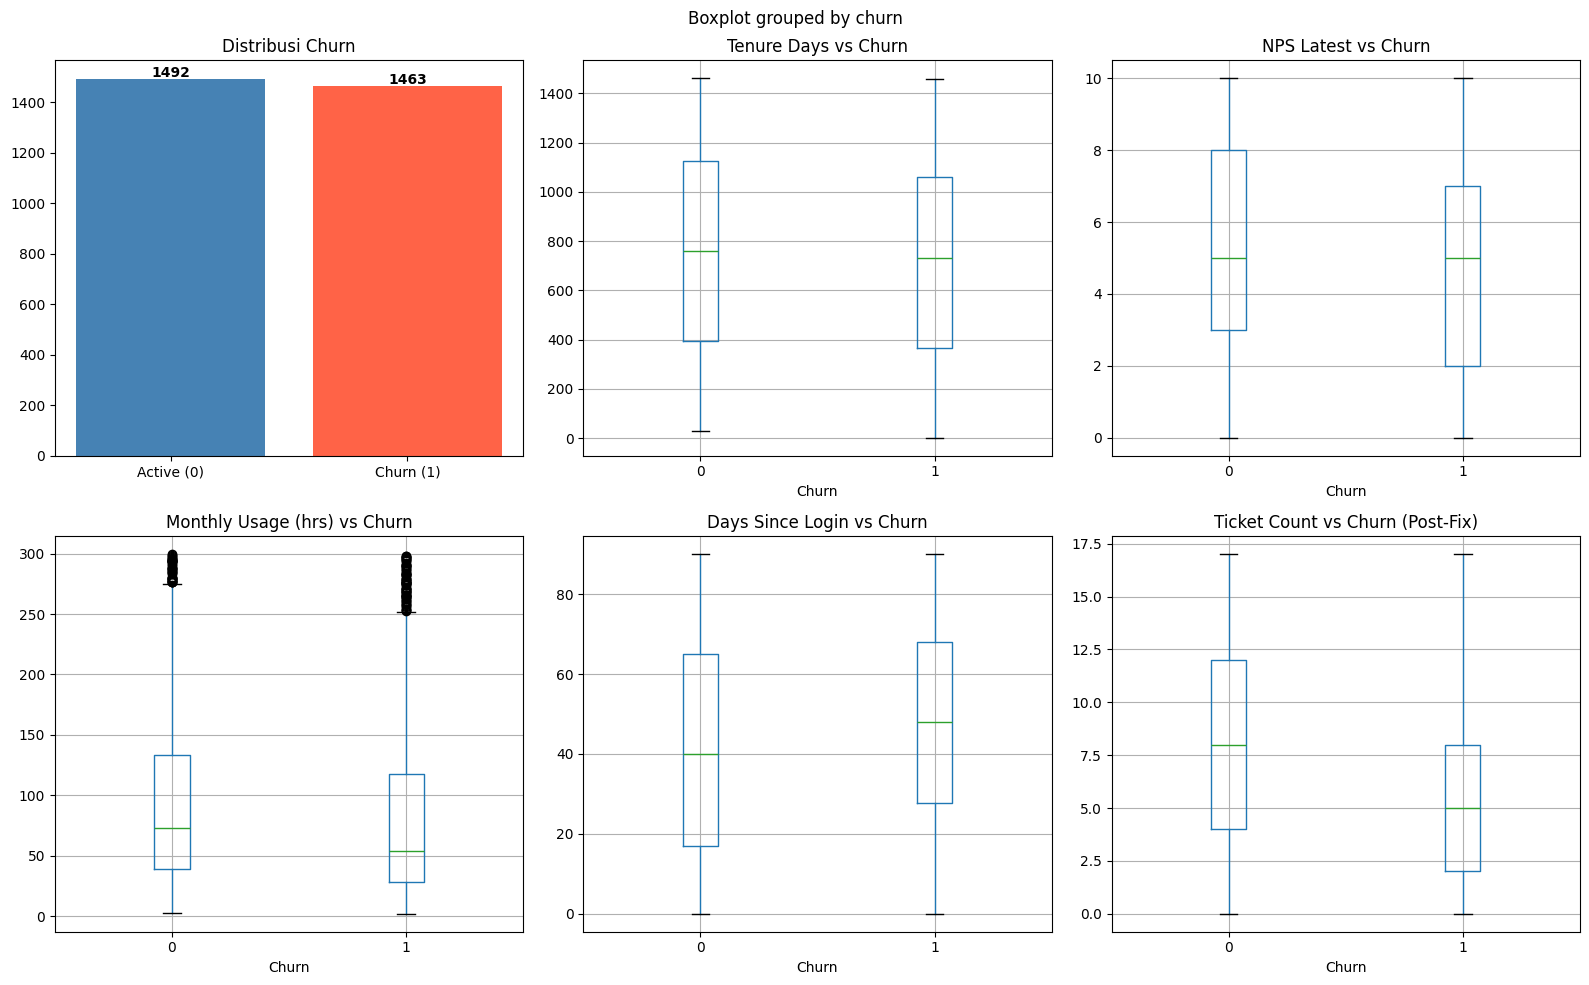

✅ Saved: eda_overview_fixed.png

STEP 11 — SEGMEN & KORELASI


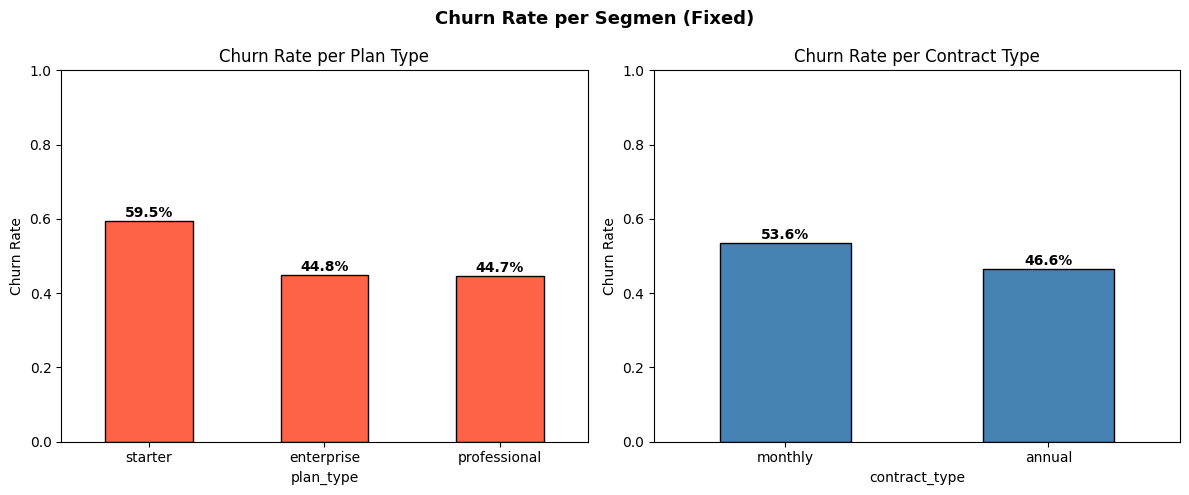

✅ Saved: eda_segmen_fixed.png

Top 15 korelasi dengan churn (post-fix):
days_since_survey         0.326877
ticket_count             -0.285019
days_since_last_ticket    0.268297
resolved_tickets         -0.267408
technical_tickets        -0.231050
billing_tickets          -0.214422
open_tickets             -0.203952
high_tickets             -0.202584
has_nps                  -0.174281
nps_count                -0.161099
critical_tickets         -0.146870
feature_req_tickets      -0.126461
days_since_login          0.100391
avg_payment_value        -0.099291
monthly_usage_hrs        -0.091303


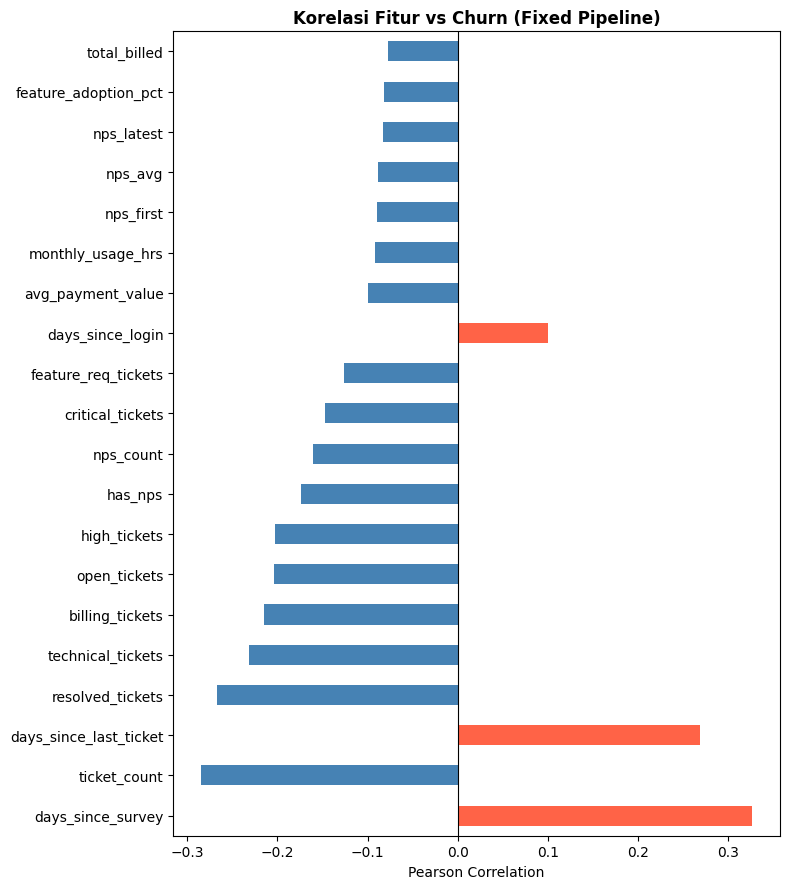

✅ Saved: correlation_fixed.png

STEP 12 — FEATURE ENGINEERING v2
Fitur engineering baru: 12
Shape setelah FE       : (2955, 50)
Missing total          : 0
Inf total              : 0

STEP 13 — ENCODING & SPLIT
  plan_type: {'enterprise': np.int64(0), 'professional': np.int64(1), 'starter': np.int64(2)}
  contract_type: {'annual': np.int64(0), 'monthly': np.int64(1)}

Train: (2364, 49) | Churn rate: 50.51%
Test : (591, 49)  | Churn rate: 50.42%
Jumlah fitur: 49

STEP 14 — RANDOM FOREST TUNED
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}

  Random Forest Tuned (Fixed)
              precision    recall  f1-score   support

      Active       0.82      0.88      0.85       293
       Churn       0.87      0.82      0.84       298

    accuracy                           0.85       591
   macro avg       0.85      0.85      0.85       591
weighted avg   

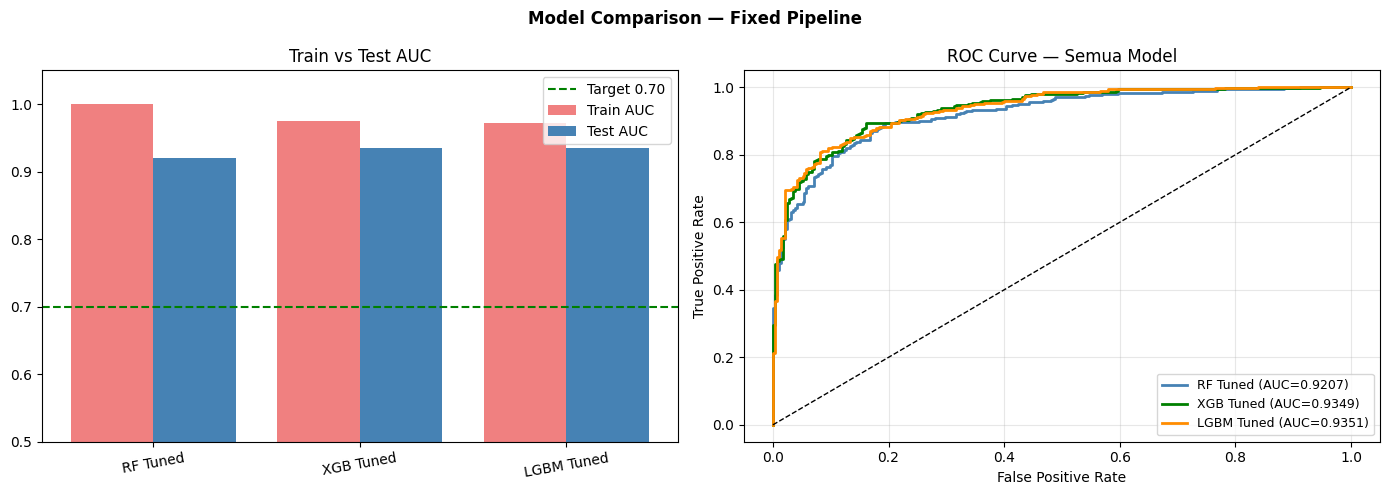

✅ Saved: model_comparison_fixed.png


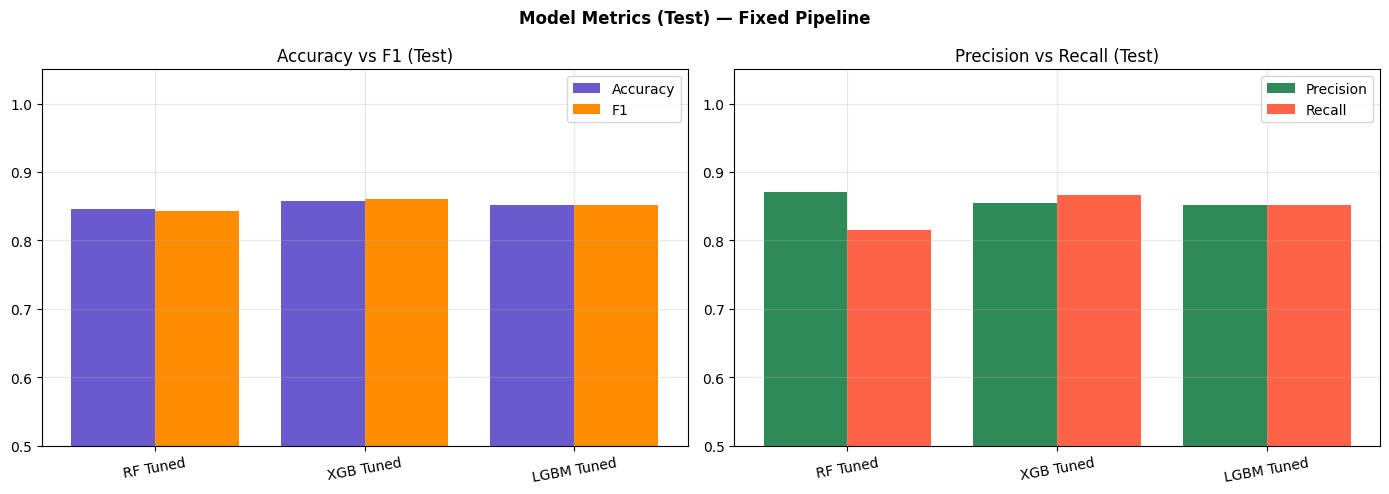

✅ Saved: model_metrics_fixed.png

STEP 18 — FEATURE IMPORTANCE (XGB Tuned)
Top 20 Feature Importance — XGB Tuned:
                feature  importance   category
          contract_type    0.096949   original
 days_since_last_ticket    0.094917   original
days_since_last_payment    0.089868   original
          payment_count    0.068903   original
     total_transactions    0.044488   original
       days_since_login    0.043109   original
      days_since_survey    0.036717   original
              plan_type    0.029659   original
           ticket_count    0.029541   original
    login_recency_ratio    0.026968 engineered
           open_tickets    0.024753   original
       resolved_tickets    0.023037   original
      technical_tickets    0.022691   original
  nps_usage_interaction    0.018038 engineered
      monthly_usage_hrs    0.017856   original
      avg_payment_value    0.016149   original
        revenue_per_day    0.015445 engineered
              nps_first    0.015179   or

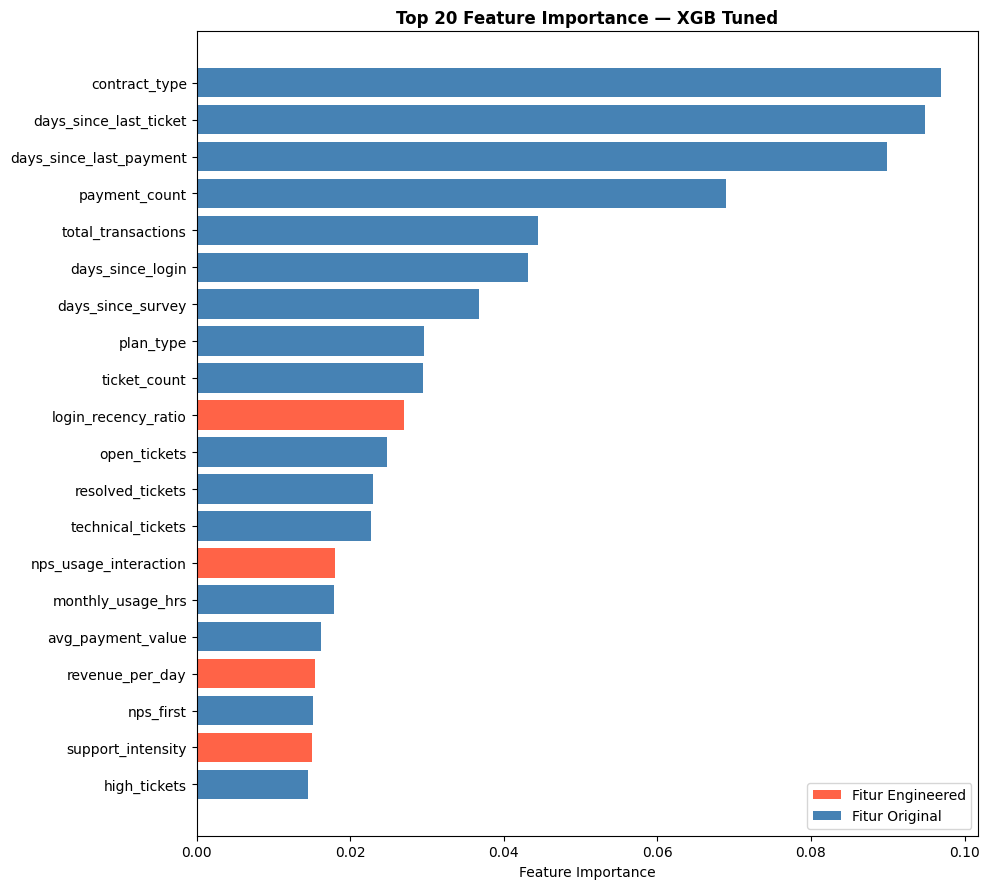

✅ Saved: feature_importance_fixed.png

STEP 18B — FEATURE IMPORTANCE (RANDOM FOREST)
Top 20 Feature Importance — Random Forest Tuned:
                feature  importance   category
 days_since_last_ticket    0.232236   original
days_since_last_payment    0.094768   original
      days_since_survey    0.070293   original
       days_since_login    0.054438   original
    login_recency_ratio    0.035866 engineered
           ticket_count    0.030068   original
       engagement_score    0.027291 engineered
       resolved_tickets    0.021386   original
      avg_payment_value    0.021210   original
      support_intensity    0.019230 engineered
            tenure_days    0.019147   original
   feature_adoption_pct    0.018860   original
  nps_usage_interaction    0.018637 engineered
      monthly_usage_hrs    0.018453   original
           total_billed    0.018060   original
         payment_health    0.017622 engineered
          payment_count    0.017467   original
     total_transacti

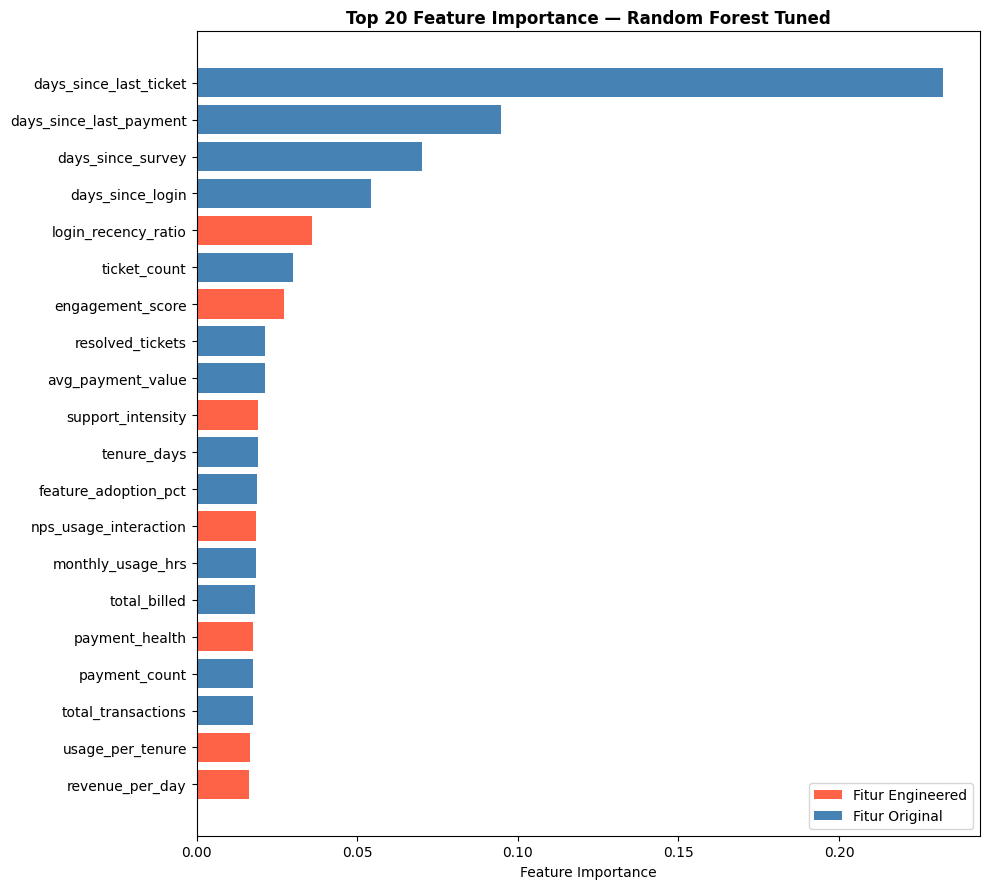

✅ Saved: feature_importance_rf_fixed.png

STEP 19 — THRESHOLD OPTIMIZATION (XGB Tuned)

Scenario              Thresh    Prec   Recall      F1     Acc  FN (missed)
------------------------------------------------------------------------
Default (0.50)         0.500   0.854    0.866   0.860   0.858           40
Best F1                0.468   0.850    0.893   0.871   0.866           32
Recall >= 0.80         0.604   0.888    0.802   0.843   0.849           59
Precision>=0.75        0.273   0.750    0.946   0.837   0.814           16


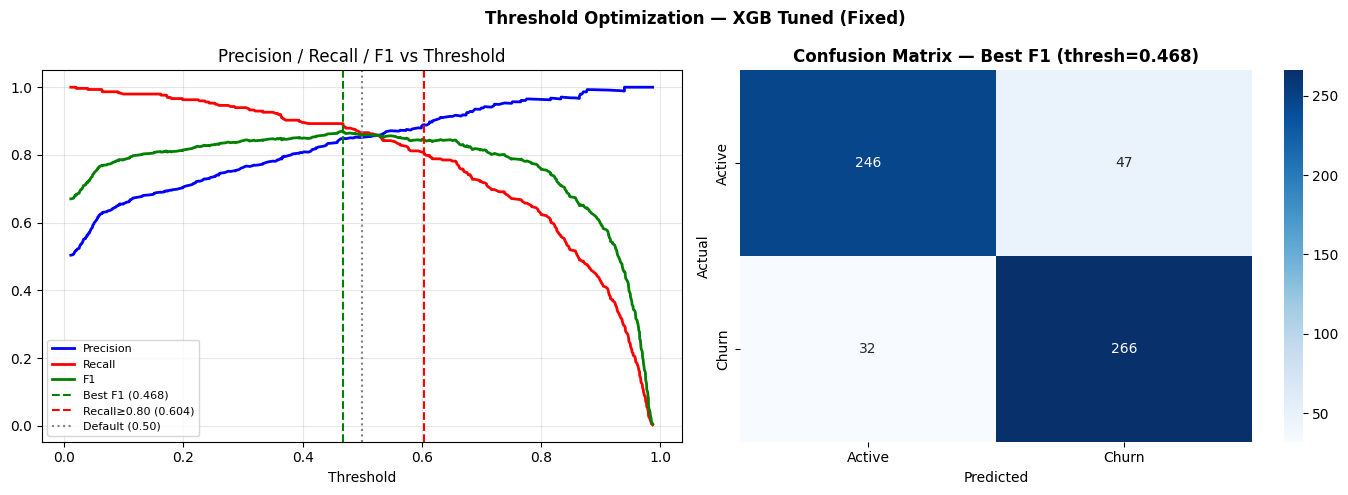

✅ Saved: threshold_optimization_fixed.png

PIPELINE SELESAI
Model terpilih : XGB Tuned
CV AUC         : 0.9404
Test AUC       : 0.9349
Gap train/test : 0.0396  ✅ OK

File yang dihasilkan:
  - eda_overview_fixed.png
  - eda_segmen_fixed.png
  - correlation_fixed.png
  - model_comparison_fixed.png
  - model_metrics_fixed.png
  - feature_importance_fixed.png
  - feature_importance_rf_fixed.png
  - threshold_optimization_fixed.png
  - merged_dataset.csv


In [1]:
"""
=============================================================
CUSTOMER CHURN ANALYSIS — COMPLETE PIPELINE (FIXED)
=============================================================
Versi : 2.0 — Full Fix
Fix yang diterapkan:
  [F1] Format tanggal tidak konsisten di support_tickets
  [F2] subscription_date → first_billing_date sebagai anchor
  [F3] Drop 2 customer dengan tenure masih negatif (C-0017, C-2990)
  [F4] Flag date_corrected untuk 23 customer yang dikoreksi
  [F5] Temporal filter: hapus semua aktivitas post-churn
       (billing, NPS, tickets hanya sebelum unsubscribed_date)
  [F6] plan_type casing tidak konsisten
  [F7] NPS score -1 (anomali) → NaN
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay,
                             precision_score, recall_score, f1_score,
                             accuracy_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# STEP 0 — LOAD DATA
# ─────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 0 — LOAD DATA")
print("=" * 60)

ca  = pd.read_csv('customer_accounts.csv')
bd  = pd.read_csv('billing_data.csv')
mu  = pd.read_csv('monthly_usage_metrics.csv')
nps = pd.read_csv('nps_surveys.csv')
st  = pd.read_csv('support_tickets.csv')

REF_DATE = pd.Timestamp('2024-12-31')

print(f"customer_accounts   : {ca.shape}")
print(f"billing_data        : {bd.shape}")
print(f"monthly_usage       : {mu.shape}")
print(f"nps_surveys         : {nps.shape}")
print(f"support_tickets     : {st.shape}")


# ─────────────────────────────────────────────────────────
# STEP 1A — FIX FORMAT TANGGAL SUPPORT TICKETS [F1]
# 1,345 baris menggunakan DD-Mon-YY bukan DD/MM/YYYY
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1A — FIX FORMAT TANGGAL SUPPORT TICKETS [F1]")
print("=" * 60)

st_raw = st.copy()

# Parse dengan dayfirst=True (DD/MM/YYYY)
st['created_date'] = pd.to_datetime(
    st['created_date'], dayfirst=True, errors='coerce'
)

# Rows yang masih NaT = format DD-Mon-YY (contoh: 24-Oct-24)
nat_mask = st['created_date'].isna()
if nat_mask.sum() > 0:
    st.loc[nat_mask, 'created_date'] = pd.to_datetime(
        st_raw.loc[nat_mask, 'created_date'],
        format='%d-%b-%y',
        errors='coerce'
    )

# Coba format alternatif untuk sisa NaT
nat_mask2 = st['created_date'].isna()
if nat_mask2.sum() > 0:
    st.loc[nat_mask2, 'created_date'] = pd.to_datetime(
        st_raw.loc[nat_mask2, 'created_date'],
        format='%d-%b-%Y',
        errors='coerce'
    )

remaining_nat = st['created_date'].isna().sum()
print(f"Baris dengan format berbeda (DD-Mon-YY) : 1,345")
print(f"NaT tersisa setelah fix                 : {remaining_nat}")
print(f"✅ Format tanggal support_tickets seragam")


# ─────────────────────────────────────────────────────────
# STEP 1B — CLEANING PER FILE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1B — CLEANING PER FILE")
print("=" * 60)

# ── customer_accounts ────────────────────────────────────
ca['subscription_date']  = pd.to_datetime(
    ca['subscription_date'], dayfirst=True, errors='coerce'
)
ca['unsubscribed_date']  = pd.to_datetime(
    ca['unsubscribed_date'], dayfirst=True, errors='coerce'
)

# [F6] Fix casing plan_type — wajib sebelum agregasi apapun
ca['plan_type']     = ca['plan_type'].str.strip().str.lower()
ca['contract_type'] = ca['contract_type'].str.strip().str.lower()

print(f"plan_type unik     : {sorted(ca['plan_type'].unique())}")
print(f"contract_type unik : {sorted(ca['contract_type'].unique())}")

# ── billing_data ─────────────────────────────────────────
bd['billing_date'] = pd.to_datetime(
    bd['billing_date'], dayfirst=True, errors='coerce'
)
bd['payment_date'] = pd.to_datetime(
    bd['payment_date'], dayfirst=True, errors='coerce'
)
bd['record_type'] = bd['record_type'].str.strip().str.lower()

# ── monthly_usage ─────────────────────────────────────────
mu['last_login_date'] = pd.to_datetime(
    mu['last_login_date'], dayfirst=True, errors='coerce'
)

# ── nps_surveys ──────────────────────────────────────────
nps['survey_date'] = pd.to_datetime(
    nps['survey_date'], dayfirst=True, errors='coerce'
)
# [F7] Fix NPS score = -1 → NaN (di luar skala 0-10)
n_invalid_nps = (nps['nps_score'] == -1).sum()
nps['nps_score'] = nps['nps_score'].replace(-1, np.nan)
print(f"\nNPS score = -1 diganti NaN: {n_invalid_nps} baris")
print(f"✅ Cleaning per file selesai")


# ─────────────────────────────────────────────────────────
# STEP 1C — FIX subscription_date → first_billing_date [F2]
# subscription_date = tanggal renewal terakhir (bukan daftar)
# first_billing_date = tanggal daftar aktual yang valid
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1C — FIX subscription_date [F2]")
print("=" * 60)

# Hitung first_billing_date per customer
first_billing = (
    bd.groupby('customer_id')['billing_date']
    .min()
    .reset_index()
    .rename(columns={'billing_date': 'first_billing_date'})
)

ca = ca.merge(first_billing, on='customer_id', how='left')

# Flag: customer yang subscription_date > first_billing_date [F4]
# (artinya subscription_date adalah renewal, bukan tanggal daftar)
ca['date_corrected'] = (
    ca['first_billing_date'] < ca['subscription_date']
).astype(int)

# Gunakan first_billing_date sebagai anchor temporal yang benar
ca['effective_start'] = ca['first_billing_date']

n_corrected = ca['date_corrected'].sum()
print(f"Customer dengan tanggal dikoreksi (date_corrected=1): {n_corrected}")
print(f"  → subscription_date diganti first_billing_date untuk {n_corrected} customer")


# ─────────────────────────────────────────────────────────
# STEP 1D — TARGET VARIABLE & TENURE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1D — TARGET VARIABLE & TENURE")
print("=" * 60)

ca['churn'] = ca['unsubscribed_date'].notna().astype(int)

# Hitung tenure pakai effective_start (first_billing_date)
ca['tenure_days'] = (
    ca['unsubscribed_date'].fillna(REF_DATE) - ca['effective_start']
).dt.days

# Cek tenure negatif setelah fix
neg_tenure = ca[ca['tenure_days'] < 0]
print(f"Tenure negatif setelah fix: {len(neg_tenure)} customer")
if len(neg_tenure) > 0:
    print(neg_tenure[['customer_id', 'effective_start',
                       'unsubscribed_date', 'tenure_days']].to_string())


# ─────────────────────────────────────────────────────────
# STEP 1E — DROP CUSTOMER TENURE MASIH NEGATIF [F3]
# C-0017 dan C-2990: first_billing_date setelah unsubscribed_date
# Tidak ada data aktif yang valid — genuinely corrupt
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1E — DROP CUSTOMER TENURE NEGATIF [F3]")
print("=" * 60)

invalid_customers = ca[ca['tenure_days'] < 0]['customer_id'].tolist()
ca = ca[ca['tenure_days'] >= 0].copy()

print(f"Customer di-drop: {invalid_customers}")
print(f"Alasan: first_billing_date > unsubscribed_date — tidak ada data valid")
print(f"Total customer setelah drop: {len(ca)}")
print(f"Churn rate setelah drop    : {ca['churn'].mean():.2%}")


# ─────────────────────────────────────────────────────────
# STEP 2 — TEMPORAL FILTER: HAPUS AKTIVITAS POST-CHURN [F5]
# Aktivitas setelah unsubscribed_date adalah temporal leakage
# HANYA berlaku untuk churn customer (churn=1)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — TEMPORAL FILTER (HAPUS POST-CHURN) [F5]")
print("=" * 60)

# Buat lookup: customer_id → unsubscribed_date
cutoff = ca[['customer_id', 'unsubscribed_date', 'churn']].copy()

# ── Filter billing_data ───────────────────────────────────
bd_merged = bd.merge(cutoff, on='customer_id', how='left')
n_bd_before = len(bd_merged)
bd_clean = bd_merged[
    ~(
        (bd_merged['churn'] == 1) &
        (bd_merged['billing_date'] > bd_merged['unsubscribed_date'])
    )
].copy()
n_removed_bd = n_bd_before - len(bd_clean)
print(f"billing_data  : {n_bd_before:,} → {len(bd_clean):,} rows (hapus {n_removed_bd:,} post-churn)")

# ── Filter nps_surveys ────────────────────────────────────
nps_merged = nps.merge(cutoff, on='customer_id', how='left')
n_nps_before = len(nps_merged)
nps_clean = nps_merged[
    ~(
        (nps_merged['churn'] == 1) &
        (nps_merged['survey_date'] > nps_merged['unsubscribed_date'])
    )
].copy()
n_removed_nps = n_nps_before - len(nps_clean)
print(f"nps_surveys   : {n_nps_before:,} → {len(nps_clean):,} rows (hapus {n_removed_nps:,} post-churn)")

# ── Filter support_tickets ────────────────────────────────
st_merged = st.merge(cutoff, on='customer_id', how='left')
n_st_before = len(st_merged)
st_clean = st_merged[
    ~(
        (st_merged['churn'] == 1) &
        (st_merged['created_date'] > st_merged['unsubscribed_date'])
    )
].copy()
n_removed_st = n_st_before - len(st_clean)
print(f"support_tickets: {n_st_before:,} → {len(st_clean):,} rows (hapus {n_removed_st:,} post-churn)")

print(f"\n✅ Total rows dihapus: {n_removed_bd + n_removed_nps + n_removed_st:,}")


# ─────────────────────────────────────────────────────────
# STEP 3 — AGREGASI billing_data
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — AGREGASI billing_data")
print("=" * 60)

payment_only = bd_clean[bd_clean['record_type'] == 'payment'].copy()
payment_only['days_late'] = (
    payment_only['payment_date'] - payment_only['billing_date']
).dt.days

billing_agg_base = bd_clean.groupby('customer_id').agg(
    total_billed        = ('payment_value', 'sum'),
    avg_payment_value   = ('payment_value', 'mean'),
    total_transactions  = ('record_type', 'count'),
    dunning_count       = ('record_type', lambda x: (x == 'dunning').sum()),
    payment_count       = ('record_type', lambda x: (x == 'payment').sum()),
    last_billing_date   = ('billing_date', 'max'),
).reset_index()

billing_agg_pay = payment_only.groupby('customer_id').agg(
    avg_days_late       = ('days_late', 'mean'),
    max_days_late       = ('days_late', 'max'),
    late_payment_count  = ('days_late', lambda x: (x > 0).sum()),
    last_payment_date   = ('payment_date', 'max'),
).reset_index()

billing_agg = billing_agg_base.merge(billing_agg_pay, on='customer_id', how='left')
billing_agg['dunning_ratio'] = (
    billing_agg['dunning_count'] / billing_agg['total_transactions']
)
billing_agg['days_since_last_payment'] = (
    REF_DATE - billing_agg['last_payment_date']
).dt.days

print(f"✅ billing_agg: {billing_agg.shape}")


# ─────────────────────────────────────────────────────────
# STEP 4 — AGREGASI nps_surveys
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4 — AGREGASI nps_surveys")
print("=" * 60)

nps_sorted = nps_clean.sort_values(['customer_id', 'survey_date'])

nps_agg = nps_sorted.groupby('customer_id').agg(
    nps_latest          = ('nps_score', 'last'),
    nps_first           = ('nps_score', 'first'),
    nps_avg             = ('nps_score', 'mean'),
    nps_min             = ('nps_score', 'min'),
    nps_count           = ('nps_score', 'count'),
    last_survey_date    = ('survey_date', 'max'),
).reset_index()

nps_agg['nps_trend']         = nps_agg['nps_latest'] - nps_agg['nps_first']
nps_agg['days_since_survey'] = (REF_DATE - nps_agg['last_survey_date']).dt.days

print(f"✅ nps_agg: {nps_agg.shape}")


# ─────────────────────────────────────────────────────────
# STEP 5 — AGREGASI support_tickets
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5 — AGREGASI support_tickets")
print("=" * 60)

# Cek orphan customers (ada di tickets tapi tidak di master)
master_ids  = set(ca['customer_id'])
ticket_ids  = set(st_clean['customer_id'])
orphan      = ticket_ids - master_ids
print(f"Orphan customers di tickets (excluded saat join): {len(orphan)}")

tickets_agg = st_clean.groupby('customer_id').agg(
    ticket_count            = ('ticket_id', 'count'),
    critical_tickets        = ('priority', lambda x: (x == 'Critical').sum()),
    high_tickets            = ('priority', lambda x: (x == 'High').sum()),
    billing_tickets         = ('category', lambda x: (x == 'Billing').sum()),
    technical_tickets       = ('category', lambda x: (x == 'Technical').sum()),
    feature_req_tickets     = ('category', lambda x: (x == 'Feature Request').sum()),
    open_tickets            = ('status',   lambda x: x.isin(['Open', 'In Progress']).sum()),
    resolved_tickets        = ('status',   lambda x: x.isin(['Resolved', 'Closed']).sum()),
    last_ticket_date        = ('created_date', 'max'),
).reset_index()

tickets_agg['open_ticket_ratio']      = (
    tickets_agg['open_tickets'] / tickets_agg['ticket_count']
)
tickets_agg['critical_ticket_ratio']  = (
    tickets_agg['critical_tickets'] / tickets_agg['ticket_count']
)
tickets_agg['days_since_last_ticket'] = (
    REF_DATE - tickets_agg['last_ticket_date']
).dt.days

print(f"✅ tickets_agg: {tickets_agg.shape}")


# ─────────────────────────────────────────────────────────
# STEP 6 — BASE TABLE & MONTHLY USAGE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6 — BASE TABLE & MONTHLY USAGE")
print("=" * 60)

mu['last_login_date'] = pd.to_datetime(
    mu['last_login_date'], dayfirst=True, errors='coerce'
)
mu['days_since_login'] = (REF_DATE - mu['last_login_date']).dt.days

print(f"✅ Base table: {ca.shape}")


# ─────────────────────────────────────────────────────────
# STEP 7 — FINAL MERGE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7 — FINAL MERGE")
print("=" * 60)

df = ca.copy()

# Merge monthly_usage (1:1)
df = df.merge(
    mu[['customer_id', 'monthly_usage_hrs',
        'feature_adoption_pct', 'days_since_login']],
    on='customer_id', how='left'
)

# Merge agregasi
df = df.merge(billing_agg,  on='customer_id', how='left')
df = df.merge(nps_agg,      on='customer_id', how='left')
df = df.merge(tickets_agg,  on='customer_id', how='left')

# ── Post-merge imputation ─────────────────────────────────

# Tiket: customer tanpa tiket → 0
ticket_zero_cols = [
    'ticket_count', 'critical_tickets', 'high_tickets',
    'billing_tickets', 'technical_tickets', 'feature_req_tickets',
    'open_tickets', 'resolved_tickets',
    'open_ticket_ratio', 'critical_ticket_ratio'
]
df[ticket_zero_cols] = df[ticket_zero_cols].fillna(0)

max_ticket = df['days_since_last_ticket'].max()
df['days_since_last_ticket'] = df['days_since_last_ticket'].fillna(
    max_ticket + 30
)

# NPS: flag, kemudian impute
df['has_nps'] = df['nps_latest'].notna().astype(int)

# nps_first: customer isi hanya 1x → first = latest
df['nps_first'] = df['nps_first'].fillna(df['nps_latest'])

# nps_count: customer tanpa NPS → 0
df['nps_count'] = df['nps_count'].fillna(0)

# nps_trend: recalculate setelah fill
df['nps_trend'] = df['nps_latest'] - df['nps_first']
df['nps_trend'] = df['nps_trend'].fillna(0)

# days_since_survey: customer tanpa NPS → max + 30
max_survey = df['days_since_survey'].max()
df['days_since_survey'] = df['days_since_survey'].fillna(max_survey + 30)

# nps numerik: impute dengan median
for col in ['nps_latest', 'nps_avg', 'nps_min', 'nps_first']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f"✅ Final merged shape : {df.shape}")
print(f"Missing values total  : {df.isnull().sum().sum()}")
print(f"\nDistribusi churn:\n{df['churn'].value_counts()}")
print(f"Churn rate: {df['churn'].mean():.2%}")

# Export merged dataset to CSV
merged_output_path = "merged_dataset.csv"
df.to_csv(merged_output_path, index=False)
print(f"✅ Saved merged data: {merged_output_path}")



# ─────────────────────────────────────────────────────────
# STEP 8 — DROP KOLOM LEAKAGE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8 — DROP KOLOM LEAKAGE")
print("=" * 60)

drop_cols = [
    'customer_id',
    'unsubscribed_date',       # sumber target → leakage
    'subscription_date',       # digantikan effective_start
    'effective_start',         # tanggal daftar aktual → sudah jadi tenure_days
    'first_billing_date',      # sudah dipakai untuk tenure_days
    'last_billing_date',       # sudah jadi days_since_last_payment
    'last_payment_date',
    'last_survey_date',
    'last_ticket_date',
    'last_login_date',         # sudah jadi days_since_login
]

df_model = df.drop(columns=drop_cols, errors='ignore')

print(f"✅ Shape siap modeling : {df_model.shape}")
print(f"Kolom ({df_model.shape[1]}):")
for i, col in enumerate(df_model.columns, 1):
    print(f"  {i:>3}. {col}")


# ─────────────────────────────────────────────────────────
# STEP 9 — HEALTH CHECK
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 9 — HEALTH CHECK")
print("=" * 60)

print(f"Shape          : {df_model.shape}")
print(f"Churn rate     : {df_model['churn'].mean():.2%}")
print(f"Missing total  : {df_model.isnull().sum().sum()}")
print(f"Inf total      : {np.isinf(df_model.select_dtypes(include=np.number)).sum().sum()}")
print(f"plan_type      : {sorted(df_model['plan_type'].unique())}")
print(f"contract_type  : {sorted(df_model['contract_type'].unique())}")
print(f"date_corrected : {df_model['date_corrected'].sum()} customer dikoreksi")
print(f"\nTipe data:\n{df_model.dtypes.value_counts()}")


# ─────────────────────────────────────────────────────────
# STEP 10 — EDA VISUAL
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 10 — EDA VISUAL")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Distribusi Fitur vs Churn (Fixed Pipeline)',
             fontsize=14, fontweight='bold')

# Distribusi churn
churn_counts = df_model['churn'].value_counts()
axes[0,0].bar(['Active (0)', 'Churn (1)'], churn_counts.values,
               color=['steelblue', 'tomato'])
axes[0,0].set_title('Distribusi Churn')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Tenure vs churn
df_model.boxplot(column='tenure_days', by='churn', ax=axes[0,1])
axes[0,1].set_title('Tenure Days vs Churn')
axes[0,1].set_xlabel('Churn')

# NPS vs churn
df_model.boxplot(column='nps_latest', by='churn', ax=axes[0,2])
axes[0,2].set_title('NPS Latest vs Churn')
axes[0,2].set_xlabel('Churn')

# Monthly usage vs churn
df_model.boxplot(column='monthly_usage_hrs', by='churn', ax=axes[1,0])
axes[1,0].set_title('Monthly Usage (hrs) vs Churn')
axes[1,0].set_xlabel('Churn')

# Days since login vs churn
df_model.boxplot(column='days_since_login', by='churn', ax=axes[1,1])
axes[1,1].set_title('Days Since Login vs Churn')
axes[1,1].set_xlabel('Churn')

# Ticket count vs churn (post-temporal-fix)
df_model.boxplot(column='ticket_count', by='churn', ax=axes[1,2])
axes[1,2].set_title('Ticket Count vs Churn (Post-Fix)')
axes[1,2].set_xlabel('Churn')

plt.tight_layout()
plt.savefig('eda_overview_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_overview_fixed.png")


# ─────────────────────────────────────────────────────────
# STEP 11 — CHURN RATE PER SEGMEN & KORELASI
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 11 — SEGMEN & KORELASI")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Rate per Segmen (Fixed)', fontsize=13, fontweight='bold')

plan_churn = df_model.groupby('plan_type')['churn'].mean().sort_values(ascending=False)
plan_churn.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Churn Rate per Plan Type')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(plan_churn.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

contract_churn = df_model.groupby('contract_type')['churn'].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Churn Rate per Contract Type')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(contract_churn.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_segmen_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_segmen_fixed.png")

# Korelasi
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
corr = df_model[num_cols].corr()['churn'].drop('churn')
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print(f"\nTop 15 korelasi dengan churn (post-fix):")
print(corr_sorted.head(15).to_string())

plt.figure(figsize=(8, 9))
top20 = corr_sorted.head(20)
colors = ['tomato' if v > 0 else 'steelblue' for v in top20.values]
top20.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur vs Churn (Fixed Pipeline)', fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('correlation_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_fixed.png")


# ─────────────────────────────────────────────────────────
# STEP 12 — FEATURE ENGINEERING v2 (PROVEN FEATURES)
# Hanya gunakan fitur yang terbukti efektif dari eksperimen
# sebelumnya (FE v2). FE v3 tidak digunakan karena menyebabkan
# overfit parah (gap train/test = 0.33)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 12 — FEATURE ENGINEERING v2")
print("=" * 60)

df_fe = df_model.copy()

# ── Grup A: Engagement ────────────────────────────────────
df_fe['engagement_score'] = (
    df_fe['monthly_usage_hrs'] *
    df_fe['feature_adoption_pct'] /
    (df_fe['days_since_login'] + 1)
).clip(upper=1e6)

df_fe['usage_per_tenure'] = (
    df_fe['monthly_usage_hrs'] /
    (df_fe['tenure_days'] / 30 + 1)
)

# ── Grup B: Payment Health ────────────────────────────────
df_fe['payment_health'] = (
    df_fe['avg_payment_value'] /
    (df_fe['dunning_count'] + 1) /
    (df_fe['avg_days_late'].fillna(0) + 1)
).clip(upper=1e6)

df_fe['ever_dunning'] = (df_fe['dunning_count'] > 0).astype(int)

df_fe['late_payment_rate'] = (
    df_fe['late_payment_count'] /
    (df_fe['payment_count'] + 1)
)

# ── Grup C: Support ───────────────────────────────────────
df_fe['support_intensity'] = (
    df_fe['ticket_count'] /
    (df_fe['tenure_days'] / 30 + 1)
)

df_fe['has_open_critical'] = (
    (df_fe['critical_tickets'] > 0) &
    (df_fe['open_ticket_ratio'] > 0)
).astype(int)

df_fe['unresolved_rate'] = (
    df_fe['open_tickets'] /
    (df_fe['ticket_count'] + 1)
)

# ── Grup D: NPS x Behavior ───────────────────────────────
df_fe['nps_usage_interaction'] = (
    df_fe['nps_latest'] * df_fe['monthly_usage_hrs']
)

df_fe['nps_tenure_interaction'] = (
    df_fe['nps_latest'] * df_fe['tenure_days']
)

# ── Grup E: Fitur baru dari temporal fix ─────────────────
# Setelah temporal fix, days_since_last_ticket menjadi lebih
# representatif — customer churn yang sebelumnya terlihat
# aktif karena tiket post-churn, sekarang jaraknya lebih jauh
df_fe['login_recency_ratio'] = (
    df_fe['days_since_login'] /
    (df_fe['tenure_days'] + 1)
)

df_fe['revenue_per_day'] = (
    df_fe['total_billed'] /
    (df_fe['tenure_days'] + 1)
)

# ── Safety check ─────────────────────────────────────────
fe_cols = [
    'engagement_score', 'usage_per_tenure', 'payment_health',
    'ever_dunning', 'late_payment_rate', 'support_intensity',
    'has_open_critical', 'unresolved_rate', 'nps_usage_interaction',
    'nps_tenure_interaction', 'login_recency_ratio', 'revenue_per_day'
]

for col in fe_cols:
    df_fe[col] = df_fe[col].replace([np.inf, -np.inf], np.nan)
    if df_fe[col].isna().sum() > 0:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

print(f"Fitur engineering baru: {len(fe_cols)}")
print(f"Shape setelah FE       : {df_fe.shape}")
print(f"Missing total          : {df_fe.isnull().sum().sum()}")
print(f"Inf total              : {np.isinf(df_fe.select_dtypes(include=np.number)).sum().sum()}")


# ─────────────────────────────────────────────────────────
# STEP 13 — ENCODING & SPLIT
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 13 — ENCODING & SPLIT")
print("=" * 60)

df_rf = df_fe.copy()

label_encoders = {}
for col in ['plan_type', 'contract_type']:
    le = LabelEncoder()
    df_rf[col] = le.fit_transform(df_rf[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_rf.drop(columns=['churn'])
y = df_rf['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape} | Churn rate: {y_train.mean():.2%}")
print(f"Test : {X_test.shape}  | Churn rate: {y_test.mean():.2%}")
print(f"Jumlah fitur: {X_train.shape[1]}")


# ─────────────────────────────────────────────────────────
# FUNGSI EVALUASI STANDAR (dengan train/test gap monitor)
# ─────────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv_score=None):
    prob_train = model.predict_proba(X_tr)[:, 1]
    prob_test  = model.predict_proba(X_te)[:, 1]
    pred_train = model.predict(X_tr)
    pred_test  = model.predict(X_te)

    train_auc = roc_auc_score(y_tr, prob_train)
    test_auc  = roc_auc_score(y_te, prob_test)
    gap       = train_auc - test_auc
    status    = "✅ OK" if gap < 0.05 else ("⚠️ Slight" if gap < 0.10 else "🔴 Overfit")

    train_acc = accuracy_score(y_tr, pred_train)
    test_acc  = accuracy_score(y_te, pred_test)
    acc_gap   = train_acc - test_acc
    acc_status = "✅ OK" if acc_gap < 0.05 else ("⚠️ Slight" if acc_gap < 0.10 else "🔴 Overfit")


    prec = precision_score(y_te, pred_test)
    rec  = recall_score(y_te, pred_test)
    f1   = f1_score(y_te, pred_test)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_te, pred_test, target_names=['Active','Churn']))
    print(f"{'CV AUC (5-fold)':<22} : {cv_score:.4f}  ← patokan" if cv_score else "")
    print(f"{'Train AUC':<22} : {train_auc:.4f}")
    print(f"{'Test  AUC':<22} : {test_auc:.4f}")
    print(f"{'Gap AUC':<22} : {gap:.4f}  {status}")
    print(f"{'Train Acc':<22} : {train_acc:.4f}")
    print(f"{'Test  Acc':<22} : {test_acc:.4f}")
    print(f"{'Acc Gap':<22} : {acc_gap:.4f}")
    print(f"{'Test Precision':<22} : {prec:.4f}")
    print(f"{'Test Recall':<22} : {rec:.4f}")
    print(f"{'Test F1':<22} : {f1:.4f}")

    return {
        'name': name, 'cv_auc': cv_score,
        'train_auc': train_auc, 'test_auc': test_auc,
        'gap': gap, 'status': status,
        'train_acc': train_acc, 'test_acc': test_acc,
        'acc_gap': acc_gap, 'acc_status': acc_status,
        'test_prec': prec, 'test_rec': rec, 'test_f1': f1,
        'prob_test': prob_test, 'pred_test': pred_test
    }


# ─────────────────────────────────────────────────────────
# STEP 14 — RANDOM FOREST TUNED
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 14 — RANDOM FOREST TUNED")
print("=" * 60)

param_dist_rf = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

rf_tuned = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter=30, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_tuned.fit(X_train, y_train)

print(f"\nBest Params: {rf_tuned.best_params_}")
result_rf = evaluate_model(
    'Random Forest Tuned (Fixed)',
    rf_tuned.best_estimator_,
    X_train, y_train, X_test, y_test,
    cv_score=rf_tuned.best_score_
)


# ─────────────────────────────────────────────────────────
# STEP 15 — XGBOOST TUNED
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 15 — XGBOOST TUNED")
print("=" * 60)

param_dist_xgb = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [2, 3, 4],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.6, 0.7, 0.8],
    'colsample_bytree' : [0.6, 0.7, 0.8],
    'min_child_weight' : [3, 5, 10],
    'gamma'            : [0.1, 0.3, 0.5],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [1, 2, 5],
}

xgb_tuned = RandomizedSearchCV(
    estimator = XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    param_distributions = param_dist_xgb,
    n_iter=40, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_tuned.fit(X_train, y_train)

print(f"\nBest Params: {xgb_tuned.best_params_}")
result_xgb = evaluate_model(
    'XGBoost Tuned (Fixed)',
    xgb_tuned.best_estimator_,
    X_train, y_train, X_test, y_test,
    cv_score=xgb_tuned.best_score_
)


# ─────────────────────────────────────────────────────────
# STEP 16 — LIGHTGBM TUNED
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 16 — LIGHTGBM TUNED")
print("=" * 60)

param_dist_lgbm = {
    'n_estimators'      : [50, 100, 200],
    'max_depth'         : [2, 3, 4],
    'learning_rate'     : [0.01, 0.05, 0.1],
    'num_leaves'        : [7, 15, 31],
    'subsample'         : [0.6, 0.7, 0.8],
    'colsample_bytree'  : [0.6, 0.7, 0.8],
    'min_child_samples' : [20, 50, 100],
    'reg_alpha'         : [0.1, 0.5, 1.0],
    'reg_lambda'        : [1.0, 2.0, 5.0],
}

lgbm_tuned = RandomizedSearchCV(
    estimator = LGBMClassifier(random_state=42, verbose=-1),
    param_distributions = param_dist_lgbm,
    n_iter=40, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
lgbm_tuned.fit(X_train, y_train)

print(f"\nBest Params: {lgbm_tuned.best_params_}")
result_lgbm = evaluate_model(
    'LightGBM Tuned (Fixed)',
    lgbm_tuned.best_estimator_,
    X_train, y_train, X_test, y_test,
    cv_score=lgbm_tuned.best_score_
)


# ─────────────────────────────────────────────────────────
# STEP 17 — PERBANDINGAN SEMUA MODEL + VISUALISASI
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 17 — PERBANDINGAN SEMUA MODEL")
print("=" * 60)

results = {
    'RF Tuned'    : result_rf,
    'XGB Tuned'   : result_xgb,
    'LGBM Tuned'  : result_lgbm,
}

print(f"\n{'Model':<25} {'CV AUC':>8} {'TrAUC':>7} {'TeAUC':>7} {'AUCGap':>7} {'TrAcc':>7} {'TeAcc':>7} {'AccGap':>7} {'Prec':>7} {'Recall':>7} {'F1':>7}")
print("-" * 110)
for name, r in results.items():
    cv = f"{r['cv_auc']:.4f}" if r['cv_auc'] else "  -   "
    print(f"{name:<25} {cv:>8} {r['train_auc']:>7.4f} {r['test_auc']:>7.4f} "
          f"{r['gap']:>7.4f} {r['train_acc']:>7.4f} {r['test_acc']:>7.4f} "
          f"{r['acc_gap']:>7.4f} {r['test_prec']:>7.4f} {r['test_rec']:>7.4f} {r['test_f1']:>7.4f}")

# Pilih model terbaik berdasarkan CV AUC
best_name = max(
    results, key=lambda k: results[k]['cv_auc'] or 0
)
best_result = results[best_name]
print(f"\n🏆 Model terpilih: {best_name} (CV AUC: {best_result['cv_auc']:.4f})")

# ── Visualisasi ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Fixed Pipeline', fontweight='bold')

# Train vs Test AUC
model_names = list(results.keys())
train_aucs  = [results[n]['train_auc'] for n in model_names]
test_aucs   = [results[n]['test_auc']  for n in model_names]
x = np.arange(len(model_names))
axes[0].bar(x - 0.2, train_aucs, 0.4, label='Train AUC', color='lightcoral')
axes[0].bar(x + 0.2, test_aucs,  0.4, label='Test AUC',  color='steelblue')
axes[0].axhline(y=0.70, color='green', linestyle='--', label='Target 0.70')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('Train vs Test AUC')
axes[0].legend()

# ROC Curve semua model
from sklearn.metrics import roc_curve
colors_roc = ['steelblue', 'green', 'darkorange']
for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['prob_test'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={r['test_auc']:.4f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Semua Model')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison_fixed.png")

# ── Metrics visualization (test) ────────────────────────
test_accs  = [results[n]['test_acc']  for n in model_names]
test_f1s   = [results[n]['test_f1']   for n in model_names]
test_precs = [results[n]['test_prec'] for n in model_names]
test_recs  = [results[n]['test_rec']  for n in model_names]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Model Metrics (Test) — Fixed Pipeline', fontweight='bold')

axes2[0].bar(x - 0.2, test_accs, 0.4, label='Accuracy', color='slateblue')
axes2[0].bar(x + 0.2, test_f1s,  0.4, label='F1',       color='darkorange')
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(model_names, rotation=10)
axes2[0].set_ylim(0.5, 1.05)
axes2[0].set_title('Accuracy vs F1 (Test)')
axes2[0].legend()
axes2[0].grid(alpha=0.3)

axes2[1].bar(x - 0.2, test_precs, 0.4, label='Precision', color='seagreen')
axes2[1].bar(x + 0.2, test_recs,  0.4, label='Recall',    color='tomato')
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(model_names, rotation=10)
axes2[1].set_ylim(0.5, 1.05)
axes2[1].set_title('Precision vs Recall (Test)')
axes2[1].legend()
axes2[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_metrics_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_metrics_fixed.png")


# ─────────────────────────────────────────────────────────
# STEP 18 — FEATURE IMPORTANCE (MODEL TERPILIH)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"STEP 18 — FEATURE IMPORTANCE ({best_name})")
print("=" * 60)

def plot_feature_importance(model, model_name, filename):
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        'feature'   : X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fe_set = set(fe_cols)
    importance_df['category'] = importance_df['feature'].apply(
        lambda x: 'engineered' if x in fe_set else 'original'
    )

    print(f"Top 20 Feature Importance — {model_name}:")
    print(importance_df.head(20).to_string(index=False))

    plt.figure(figsize=(10, 9))
    top20 = importance_df.head(20)
    colors_fi = ['tomato' if c == 'engineered' else 'steelblue'
                 for c in top20['category'][::-1]]
    plt.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors_fi)

    from matplotlib.patches import Patch
    plt.legend(handles=[
        Patch(facecolor='tomato',    label='Fitur Engineered'),
        Patch(facecolor='steelblue', label='Fitur Original'),
    ], loc='lower right')

    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importance — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

# Pilih model yang tepat
if 'RF' in best_name:
    best_model = rf_tuned.best_estimator_
elif 'XGB' in best_name:
    best_model = xgb_tuned.best_estimator_
else:
    best_model = lgbm_tuned.best_estimator_

plot_feature_importance(best_model, best_name, 'feature_importance_fixed.png')


# ─────────────────────────────────────────────────────────
# STEP 18B — FEATURE IMPORTANCE (RANDOM FOREST)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 18B — FEATURE IMPORTANCE (RANDOM FOREST)")
print("=" * 60)
rf_model = rf_tuned.best_estimator_
plot_feature_importance(rf_model, 'Random Forest Tuned', 'feature_importance_rf_fixed.png')


# ─────────────────────────────────────────────────────────
# STEP 19 — THRESHOLD OPTIMIZATION (MODEL TERPILIH)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"STEP 19 — THRESHOLD OPTIMIZATION ({best_name})")
print("=" * 60)

from sklearn.metrics import precision_recall_curve, f1_score

best_prob = best_result['prob_test']
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, best_prob)
f1_arr = (2 * precision_arr * recall_arr /
          (precision_arr + recall_arr + 1e-9))

idx_f1        = np.argmax(f1_arr)
thresh_f1     = thresholds[idx_f1]

recall_80_idx = np.where(recall_arr >= 0.80)[0]
thresh_r80    = thresholds[recall_80_idx[-1]] if len(recall_80_idx) > 0 else thresh_f1

prec_75_idx   = np.where(precision_arr >= 0.75)[0]
thresh_p75    = thresholds[prec_75_idx[0]] if len(prec_75_idx) > 0 else thresh_f1

scenarios = {
    'Default (0.50)' : 0.50,
    'Best F1'        : thresh_f1,
    'Recall >= 0.80' : thresh_r80,
    'Precision>=0.75': thresh_p75,
}

print(f"\n{'Scenario':<20} {'Thresh':>7} {'Prec':>7} {'Recall':>8} "
      f"{'F1':>7} {'Acc':>7} {'FN (missed)':>12}")
print("-" * 72)

for name, thresh in scenarios.items():
    y_pred_t = (best_prob >= thresh).astype(int)
    cm       = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    acc  = (tp + tn) / len(y_test)
    print(f"{name:<20} {thresh:>7.3f} {prec:>7.3f} {rec:>8.3f} "
          f"{f1:>7.3f} {acc:>7.3f} {fn:>12}")

# Visualisasi threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Threshold Optimization — {best_name} (Fixed)',
             fontweight='bold')

axes[0].plot(thresholds, precision_arr[:-1], 'b-', linewidth=2, label='Precision')
axes[0].plot(thresholds, recall_arr[:-1],    'r-', linewidth=2, label='Recall')
axes[0].plot(thresholds, f1_arr[:-1],        'g-', linewidth=2, label='F1')
axes[0].axvline(x=thresh_f1, color='green', linestyle='--',
                label=f'Best F1 ({thresh_f1:.3f})')
axes[0].axvline(x=thresh_r80, color='red', linestyle='--',
                label=f'Recall≥0.80 ({thresh_r80:.3f})')
axes[0].axvline(x=0.5, color='gray', linestyle=':',
                label='Default (0.50)')
axes[0].set_xlabel('Threshold')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Confusion Matrix Best F1
y_pred_best = (best_prob >= thresh_f1).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churn'],
            yticklabels=['Active', 'Churn'], ax=axes[1])
axes[1].set_title(f'Confusion Matrix — Best F1 (thresh={thresh_f1:.3f})',
                  fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('threshold_optimization_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: threshold_optimization_fixed.png")

print("\n" + "=" * 60)
print("PIPELINE SELESAI")
print("=" * 60)
print(f"Model terpilih : {best_name}")
print(f"CV AUC         : {best_result['cv_auc']:.4f}")
print(f"Test AUC       : {best_result['test_auc']:.4f}")
print(f"Gap train/test : {best_result['gap']:.4f}  {best_result['status']}")
print(f"\nFile yang dihasilkan:")
print("  - eda_overview_fixed.png")
print("  - eda_segmen_fixed.png")
print("  - correlation_fixed.png")
print("  - model_comparison_fixed.png")
print("  - model_metrics_fixed.png")
print("  - feature_importance_fixed.png")
print("  - feature_importance_rf_fixed.png")
print("  - threshold_optimization_fixed.png")
print("  - merged_dataset.csv")